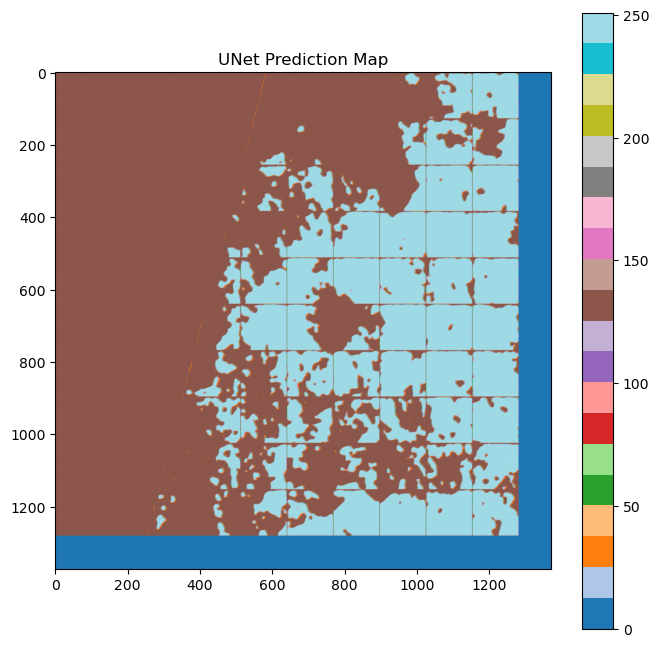

In [21]:
import rasterio
import matplotlib.pyplot as plt


# Opening prediction map (pred_unet.tif)
pred_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\pred_unet.tif"

with rasterio.open(pred_path) as src:
    pred = src.read(1)

plt.figure(figsize=(8, 8))
plt.imshow(pred, cmap="tab20")
plt.title("UNet Prediction Map")
plt.colorbar()
plt.show()

In [22]:
# Opening the stacked Sentinel-2 raster (sentinel2_stack.tif)
stack_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\sentinel2_stack.tif"

with rasterio.open(stack_path) as src:
    stack = src.read()  # shape = (bands, H, W)
    print("Bands, Height, Width =", stack.shape)

Bands, Height, Width = (6, 1372, 1372)


In [23]:
# Opening model evaluation metrics (metrics.json)
import json

metrics_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\metrics.json"

with open(metrics_path, "r") as f:
    metrics = json.load(f)

print("Keys:", metrics.keys())
print("First 10 IOU values:", metrics["per_class_iou"][:10])

Keys: dict_keys(['per_class_iou', 'mean_iou', 'f1_macro'])
First 10 IOU values: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


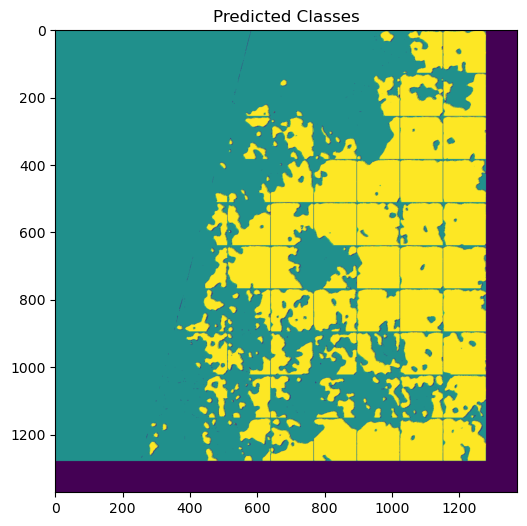

In [24]:
# display a single predicted band as a color image
plt.figure(figsize=(6,6))
plt.imshow(pred, cmap="viridis")
plt.title("Predicted Classes")
plt.show()

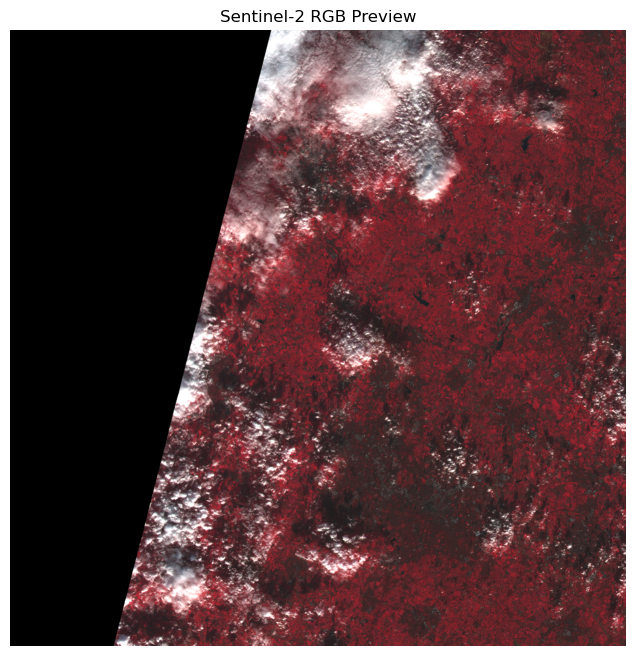

In [25]:
# Show Sentinel-2 RGB Preview 
import numpy as np
import matplotlib.pyplot as plt
import rasterio

stack_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\sentinel2_stack.tif"

with rasterio.open(stack_path) as src:
    stack = src.read()  # (bands, H, W)

# assuming band order includes B4, B3, B2 in [3,2,1] or similar — adjust if needed
try:
    rgb = np.stack([stack[3], stack[2], stack[1]], axis=-1)  
    rgb = rgb / rgb.max()  # normalize
except:
    print("Could not extract RGB bands. Check your band order.")
    rgb = None

if rgb is not None:
    plt.figure(figsize=(8,8))
    plt.imshow(rgb)
    plt.title("Sentinel-2 RGB Preview")
    plt.axis("off")
    plt.show()

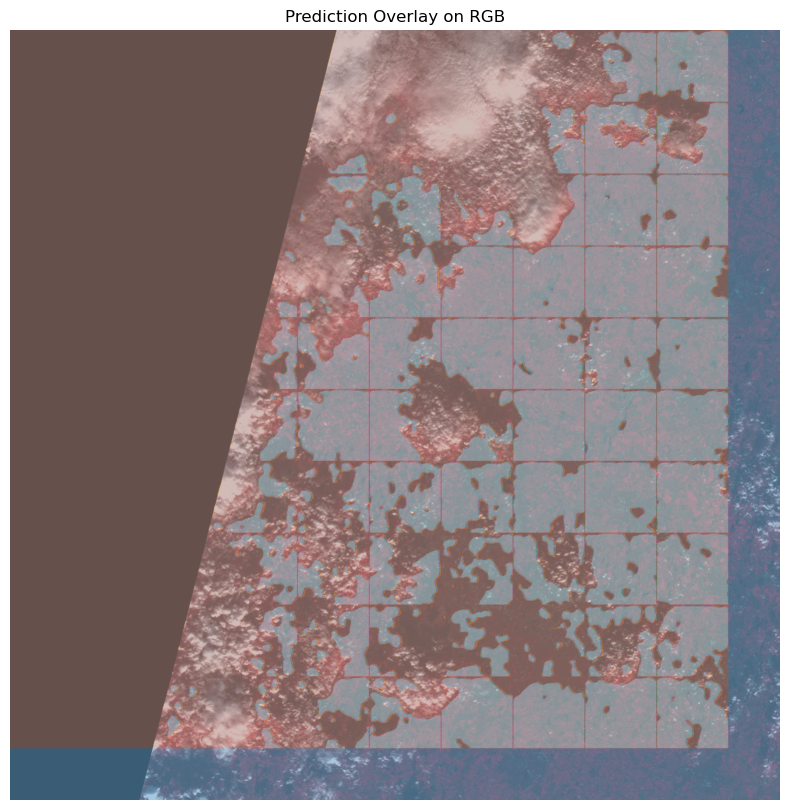

In [26]:
# Overlaying Prediction on RGB (semi-transparent)
if rgb is not None:
    plt.figure(figsize=(10,10))

    plt.imshow(rgb, alpha=0.7)             # RGB base
    plt.imshow(pred, cmap="tab20", alpha=0.4)  # Prediction overlay

    plt.title("Prediction Overlay on RGB")
    plt.axis("off")
    plt.show()

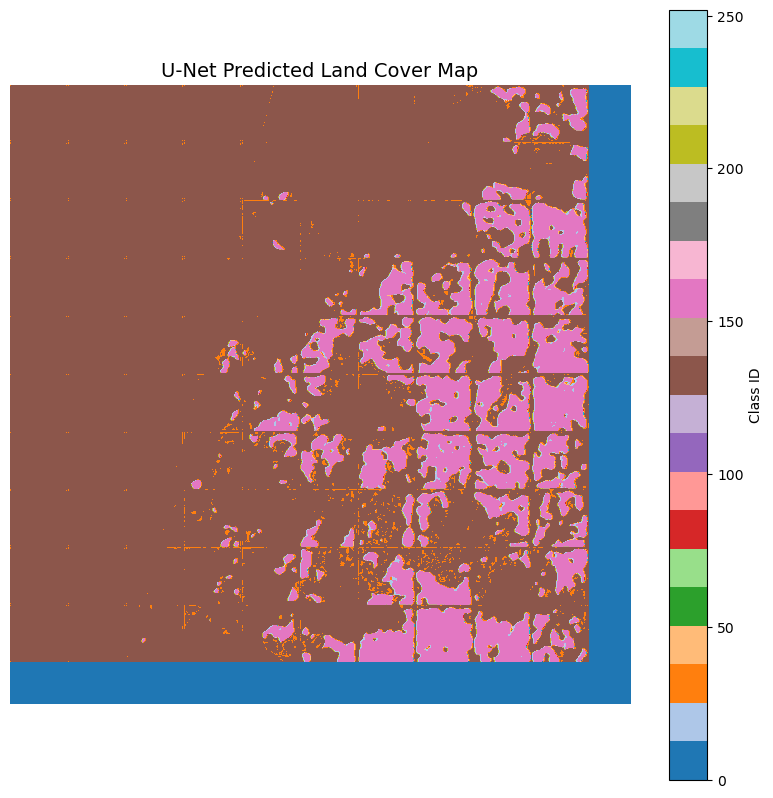

In [30]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

tif_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\pred_unet_eval.tif"

with rasterio.open(tif_path) as src:
    pred = src.read(1)   # read single band (class indices)
    cmap = plt.get_cmap('tab20')  # colorful map for classes

plt.figure(figsize=(10, 10))
im = plt.imshow(pred, cmap=cmap, interpolation='nearest')
plt.title("U-Net Predicted Land Cover Map", fontsize=14)
plt.colorbar(im, label="Class ID")
plt.axis("off")
plt.show()

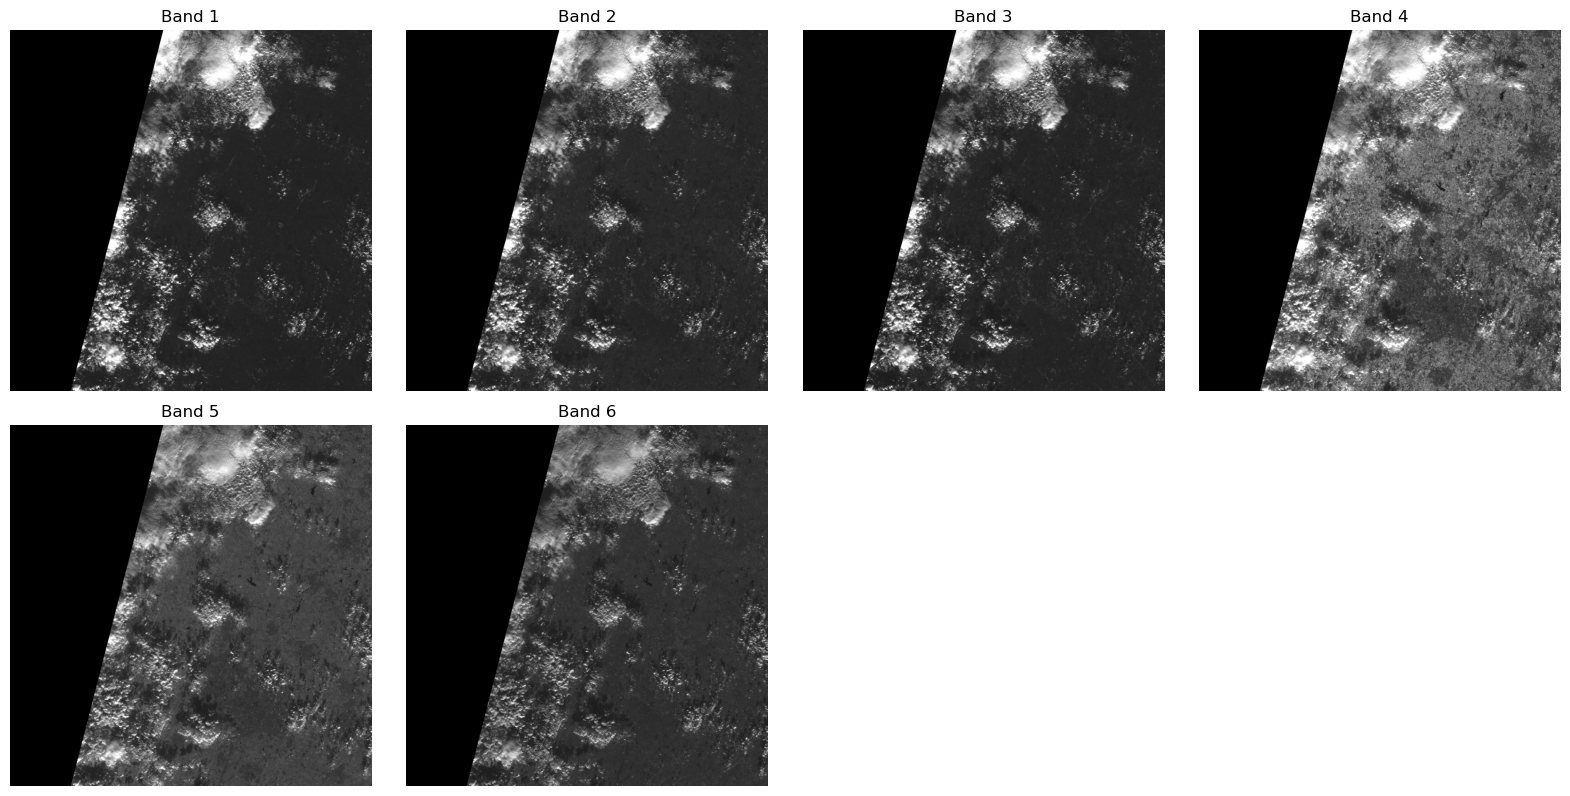

In [31]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

stack_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\sentinel2_stack.tif"

with rasterio.open(stack_path) as src:
    n_bands = src.count
    bands = src.read()

plt.figure(figsize=(16, 12))
for i in range(n_bands):
    plt.subplot(3, 4, i+1)   # change layout depending on your band count
    plt.imshow(bands[i], cmap='gray')
    plt.title(f"Band {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


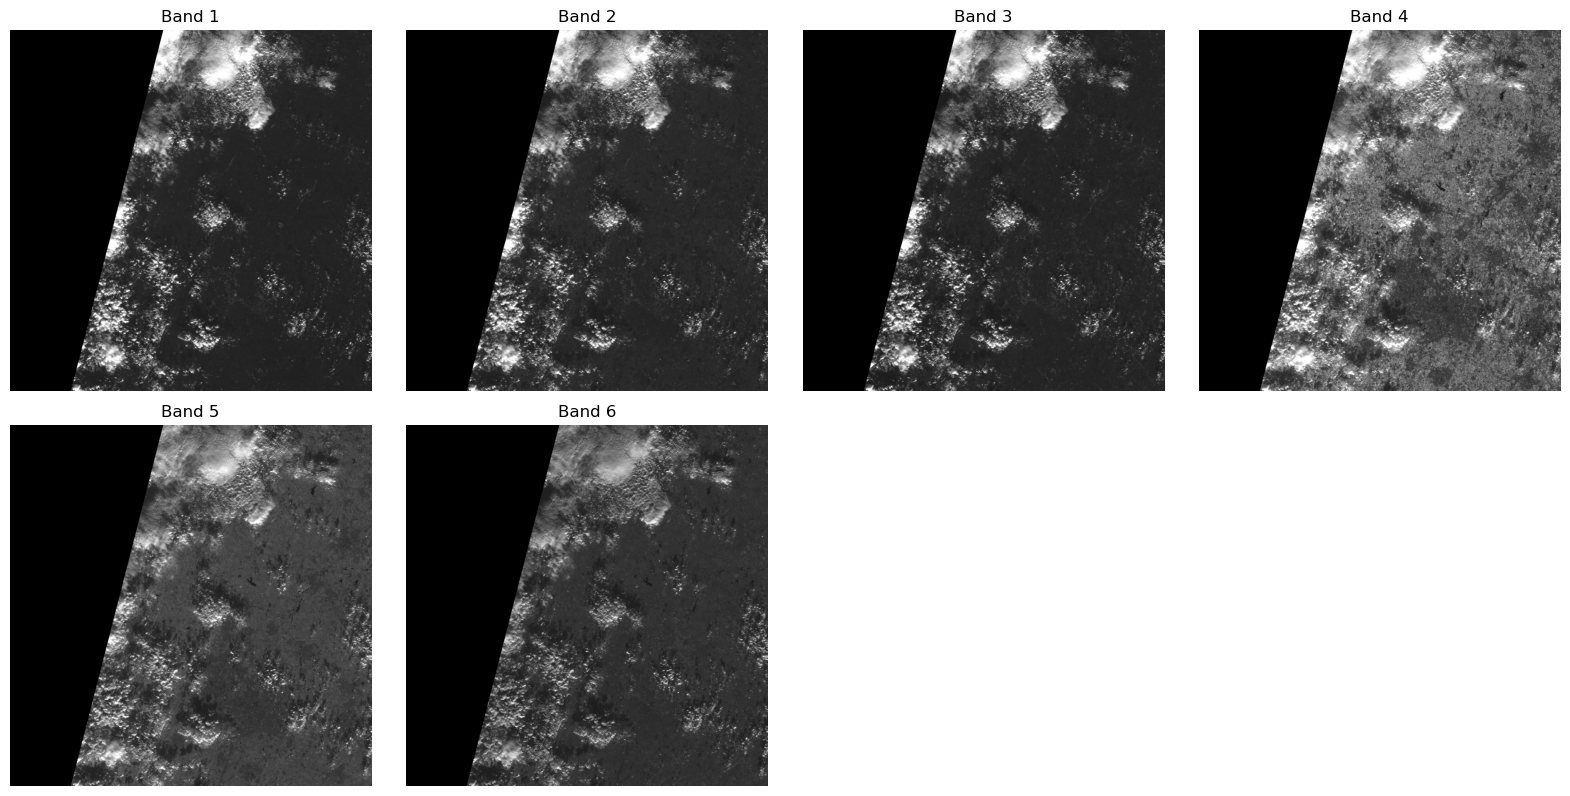

In [33]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

stack_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\sentinel2_stack.tif"

with rasterio.open(stack_path) as src:
    n_bands = src.count
    bands = src.read()

plt.figure(figsize=(16, 12))
for i in range(n_bands):
    plt.subplot(3, 4, i+1)   # change layout depending on your band count
    plt.imshow(bands[i], cmap='gray')
    plt.title(f"Band {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [36]:
file_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\rf_report.txt"

with open(file_path, "r") as f:
    lines = f.readlines()

# Show first 20 lines
print("----- FIRST 20 LINES -----")
for l in lines[:20]:
    print(l.strip())

# Show last 20 lines
print("\n----- LAST 20 LINES -----")
for l in lines[-20:]:
    print(l.strip())


----- FIRST 20 LINES -----
precision    recall  f1-score   support

31       0.00      0.00      0.00         1
41       0.00      0.00      0.00         1
54       0.00      0.00      0.00         1
56       0.00      0.00      0.00         1
67       0.00      0.00      0.00         2
70       0.00      0.00      0.00         1
77       0.00      0.00      0.00         1
80       0.00      0.00      0.00         1
90       0.00      0.00      0.00         1
91       0.00      0.00      0.00         1
93       0.00      0.00      0.00         1
95       0.00      0.00      0.00         3
98       0.00      0.00      0.00         1
99       0.00      0.00      0.00         1
103       0.00      0.00      0.00         1
104       0.00      0.00      0.00         0
106       0.00      0.00      0.00         3
109       0.00      0.00      0.00         1

----- LAST 20 LINES -----
1455       0.00      0.00      0.00         1
1463       0.00      0.00      0.00         1
1476       0.00  

In [37]:
keywords = ["precision", "recall", "f1-score", "accuracy"]
file_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\rf_report.txt"

with open(file_path, "r") as f:
    for line in f:
        if any(k in line.lower() for k in keywords):
            print(line.strip())


precision    recall  f1-score   support
accuracy                           0.01      3000


In [38]:
import re

file_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\rf_report.txt"

with open(file_path, "r") as f:
    for line in f:
        match = re.search(r"\s+(\d+)\s+([\d\.]+)\s+([\d\.]+)\s+([\d\.]+)", line)
        if match:
            cls, p, r, f1 = match.groups()
            if float(f1) > 0:
                print(f"Class {cls} → F1 = {f1}, Precision = {p}, Recall = {r}")


Class 260 → F1 = 0.12, Precision = 0.12, Recall = 0.11
Class 284 → F1 = 0.08, Precision = 0.06, Recall = 0.14
Class 311 → F1 = 0.09, Precision = 0.20, Recall = 0.06
Class 316 → F1 = 0.14, Precision = 0.09, Recall = 0.30
Class 329 → F1 = 0.04, Precision = 0.02, Recall = 0.11
Class 353 → F1 = 0.12, Precision = 0.13, Recall = 0.12
Class 364 → F1 = 0.04, Precision = 0.03, Recall = 0.06
Class 415 → F1 = 0.02, Precision = 0.01, Recall = 1.00
Class 440 → F1 = 0.07, Precision = 0.06, Recall = 0.11
Class 491 → F1 = 0.14, Precision = 0.17, Recall = 0.12
Class 515 → F1 = 0.17, Precision = 0.11, Recall = 0.33
Class 681 → F1 = 0.15, Precision = 0.14, Recall = 0.17
Class 896 → F1 = 0.33, Precision = 0.25, Recall = 0.50


⚠️ Ground truth NOT loaded. Skipping that plot.


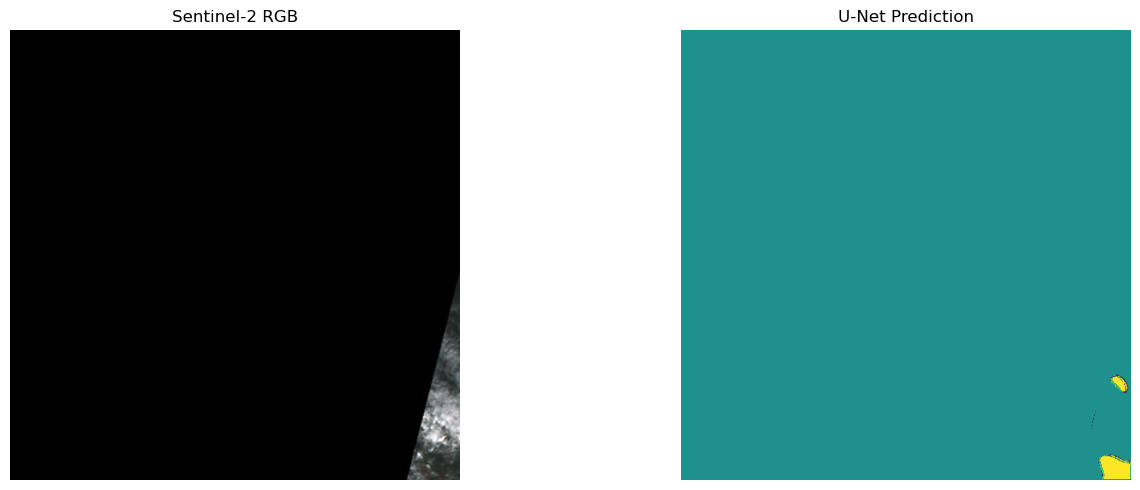

In [41]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
stack_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\sentinel2_stack.tif"
label_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\aligned_labels_remapped.tif"
pred_path  = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\pred_unet.tif"
# Load Sentinel-2 RGB
with rasterio.open(stack_path) as src:
    rgb = src.read([3, 2, 1])
    rgb = np.transpose(rgb, (1, 2, 0))
# Load prediction
with rasterio.open(pred_path) as src:
    pred = src.read(1)
# Try loading GT safely
gt = None
try:
    with rasterio.open(label_path) as src:
        gt = src.read(1)
        print("Ground truth loaded!")
except:
    print("⚠️ Ground truth NOT loaded. Skipping that plot.")
# Crop region
r0, r1 = 0, 512
c0, c1 = 0, 512
rgb_crop = rgb[r0:r1, c0:c1, :]
pred_crop = pred[r0:r1, c0:c1]
plt.figure(figsize=(15, 5))
# RGB
plt.subplot(1, 3 if gt is not None else 2, 1)
plt.title("Sentinel-2 RGB")
plt.imshow(rgb_crop)
plt.axis("off")
# GT
if gt is not None:
    gt_crop = gt[r0:r1, c0:c1]
    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(gt_crop, vmin=0)
    plt.axis("off")
# Prediction
plt.subplot(1, 3 if gt is not None else 2, 3 if gt is not None else 2)
plt.title("U-Net Prediction")
plt.imshow(pred_crop, vmin=0)
plt.axis("off")
plt.tight_layout()
plt.show()

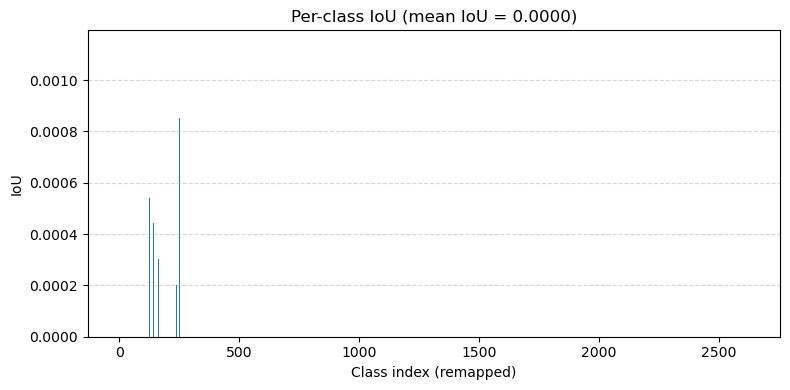

In [42]:
import json
import matplotlib.pyplot as plt
import numpy as np

metrics_path = r"C:\Users\ASUS\Desktop\Desertation\Outputs\output_run1\metrics.json"

with open(metrics_path, "r") as f:
    metrics = json.load(f)

ious = np.array(metrics["per_class_iou"])
mean_iou = metrics["mean_iou"]

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(ious) + 1), ious)
plt.xlabel("Class index (remapped)")
plt.ylabel("IoU")
plt.title(f"Per-class IoU (mean IoU = {mean_iou:.4f})")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
